# Analysis Extended with S&P 500

This notebook repeats the original analysis and adds the S&P 500 to the return, correlation, VAR, stability, and Granger-causality analyses.


# 1. Data Preparation

Import packages, merge the source datasets, and construct monthly market returns.


## 1.1. Package Imports

Load the Python packages used for data handling, plotting, correlation tests, and VAR analysis.


In [44]:
from pathlib import Path

import numpy as np
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy
import statsmodels

from IPython.display import display, HTML
from scipy.stats import norm, pearsonr
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

print("All packages imported successfully.")


All packages imported successfully.


## 1.2. Data Merging

Read stock price CSV files and the monthly sentiment Excel file, clean them, merge by month, and export the merged dataset.


In [45]:
# Project paths
PROJECT_ROOT = Path(r"C:\Users\20945\Desktop\data\project")
DATA_DIR = PROJECT_ROOT / "dataset"
STOCK_DIR = DATA_DIR / "stock" / "monthly"
OUTPUT_PATH = PROJECT_ROOT / "dataset" / "outputs" / "stock_sentiment_dataset_sp500.xlsx"

# Input files
def find_sp500_file(stock_dir: Path) -> Path:
    """Find the S&P 500 CSV while allowing common filename variations."""
    name_patterns = ("s&p 500", "s&p500", "sp500", "s_p_500", "s-p-500")
    candidates = [
        path
        for path in stock_dir.glob("*.csv")
        if any(pattern in path.name.lower() for pattern in name_patterns)
    ]

    if not candidates:
        raise FileNotFoundError(
            "No S&P 500 CSV was found in dataset/stock. "
            "Add a CSV whose filename contains S&P 500, S&P500, or SP500."
        )

    if len(candidates) > 1:
        raise ValueError(
            "Multiple possible S&P 500 CSV files were found: "
            + ", ".join(path.name for path in candidates)
        )

    return candidates[0]


SP500_FILE = find_sp500_file(STOCK_DIR)

STOCK_FILES = {
    "shanghai_price": STOCK_DIR / "Shanghai Composite Monthly Historical Results Price Data (1).csv",
    "nikkei_price": STOCK_DIR / "Nikkei 225 Monthly Historical Results Price Data (1).csv",
    "kospi_price": STOCK_DIR / "KOSPI Monthly Historical Results Price Data (1).csv",
    "hang_seng_price": STOCK_DIR / "Hang Seng Monthly Historical Results Price Data (1).csv",
    "singapore_sti_price": STOCK_DIR / "FTSE Straits Times Singapore Monthly Historical Results Price Data (2).csv",
    "sp500_price": SP500_FILE,
}

SENTIMENT_FILE = DATA_DIR / "Investor_Sentiment_Monthly.xlsx.xlsx"

# Settings
CUTOFF_MONTH = "2023-08"
SENTIMENT_COLUMNS = ["month", "DCEF", "RIPO", "NIPO", "NA", "TURN", "CCI", "ISI", "StdISI"]


def load_stock_price(file_path: Path, price_column_name: str) -> pd.DataFrame:
    stock = pd.read_csv(file_path)

    # Parse stock dates as dd/mm/yyyy
    stock["Date"] = pd.to_datetime(stock["Date"], format="%d/%m/%Y")

    # Convert to monthly format YYYY-MM
    stock["month"] = stock["Date"].dt.strftime("%Y-%m")

    # Keep only observations up to 2023-08 and only the Price column
    stock = stock.loc[
        stock["month"] <= CUTOFF_MONTH,
        ["month", "Price"]
    ].copy()

    # Rename Price column
    stock = stock.rename(columns={"Price": price_column_name})

    # Sort by month
    stock = stock.sort_values("month").reset_index(drop=True)

    return stock


def load_sentiment(file_path: Path) -> pd.DataFrame:
    sentiment = pd.read_excel(file_path, sheet_name="sheet1")

    # Remove first two metadata/unit rows
    sentiment = sentiment.iloc[2:].copy()

    # Rename monthly date column
    sentiment = sentiment.rename(columns={"SgnMonth": "month"})

    # Convert to monthly format YYYY-MM
    sentiment["month"] = pd.to_datetime(
        sentiment["month"],
        format="%Y-%m"
    ).dt.strftime("%Y-%m")

    # Keep only required sentiment variables
    sentiment = sentiment[SENTIMENT_COLUMNS].copy()

    # Convert sentiment variables to numeric
    for column in SENTIMENT_COLUMNS[1:]:
        sentiment[column] = pd.to_numeric(sentiment[column], errors="coerce")

    sentiment = sentiment.sort_values("month").reset_index(drop=True)

    return sentiment


# Read and clean stock datasets
stock_dataframes = [
    load_stock_price(file_path, price_column_name)
    for price_column_name, file_path in STOCK_FILES.items()
]

# Merge stock datasets
master_df = stock_dataframes[0]

for stock_df in stock_dataframes[1:]:
    master_df = master_df.merge(stock_df, on="month", how="inner")

# Read and clean sentiment dataset
sentiment_df = load_sentiment(SENTIMENT_FILE)

# Merge stock data with sentiment data
master_df = master_df.merge(sentiment_df, on="month", how="inner")

# Sort final dataset
master_df = master_df.sort_values("month").reset_index(drop=True)

# Export final dataset
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
master_df.to_excel(OUTPUT_PATH, index=False)

# Notebook outputs
print(f"Exported master dataset to: {OUTPUT_PATH}")

print(f"\nFinal row count: {len(master_df):,}")
print(f"Date range: {master_df['month'].min()} to {master_df['month'].max()}")

print("\nMissing value summary:")
print(master_df.isna().sum())

print("\nColumn names:")
print(list(master_df.columns))

# Show first few rows
master_df.head()

Exported master dataset to: C:\Users\20945\Desktop\data\project\dataset\outputs\stock_sentiment_dataset_sp500.xlsx

Final row count: 248
Date range: 2003-01 to 2023-08

Missing value summary:
month                  0
shanghai_price         0
nikkei_price           0
kospi_price            0
hang_seng_price        0
singapore_sti_price    0
sp500_price            0
DCEF                   0
RIPO                   0
NIPO                   0
NA                     0
TURN                   0
CCI                    0
ISI                    0
StdISI                 0
dtype: int64

Column names:
['month', 'shanghai_price', 'nikkei_price', 'kospi_price', 'hang_seng_price', 'singapore_sti_price', 'sp500_price', 'DCEF', 'RIPO', 'NIPO', 'NA', 'TURN', 'CCI', 'ISI', 'StdISI']


,month,shanghai_price,nikkei_price,kospi_price,hang_seng_price,singapore_sti_price,sp500_price,DCEF,RIPO,NIPO,NA,TURN,CCI,ISI,StdISI
0,2003-01,"1,499.82","8,339.94",591.86,"9,258.95","1,253.98",855.70,-0.1034,0.9050,5,3.97,0.1054,97.5,26.44,-1.26
1,2003-02,"1,511.93","8,363.04",575.43,"9,122.66","1,236.36",841.10,-0.1117,0.7691,3,2.85,0.1928,97.7,25.30,-1.05
2,2003-03,"1,510.58","7,972.71",535.70,"8,634.45","1,235.25",848.20,-0.0941,0.6831,6,3.26,0.1328,97.8,26.20,-1.27
3,2003-04,"1,521.44","7,831.42",599.35,"8,717.22","1,251.60",916.90,-0.1399,1.1853,5,5.69,0.1218,97.6,27.69,-1.07
4,2003-05,"1,576.26","8,424.51",633.42,"9,487.38","1,324.56",963.60,-0.1892,1.0623,2,4.21,0.3197,88.7,24.05,-0.70


## 1.3. Return Construction

Convert stock price columns to numeric values, calculate monthly log returns, and create the analysis dataset.


In [46]:
# Convert stock price columns from string to numeric
price_vars = [
    "shanghai_price",
    "nikkei_price",
    "kospi_price",
    "hang_seng_price",
    "singapore_sti_price",
    "sp500_price"
]

for col in price_vars:
    master_df[col] = (
        master_df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

# Generate monthly log return variables
master_df["r_shanghai"] = np.log(master_df["shanghai_price"] / master_df["shanghai_price"].shift(1)) * 100
master_df["r_nikkei"] = np.log(master_df["nikkei_price"] / master_df["nikkei_price"].shift(1)) * 100
master_df["r_kospi"] = np.log(master_df["kospi_price"] / master_df["kospi_price"].shift(1)) * 100
master_df["r_hangseng"] = np.log(master_df["hang_seng_price"] / master_df["hang_seng_price"].shift(1)) * 100
master_df["r_singapore"] = np.log(master_df["singapore_sti_price"] / master_df["singapore_sti_price"].shift(1)) * 100
master_df["r_sp500"] = np.log(master_df["sp500_price"] / master_df["sp500_price"].shift(1)) * 100

# Create analysis dataset and remove missing values
analysis_vars = [
    "month",
    "shanghai_price",
    "nikkei_price",
    "kospi_price",
    "hang_seng_price",
    "singapore_sti_price",
    "sp500_price",
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "DCEF",
    "RIPO",
    "NIPO",
    "NA",
    "TURN",
    "CCI",
    "ISI",
    "StdISI"
]

analysis_df = master_df[analysis_vars].dropna().copy()
analysis_df["month_dt"] = pd.to_datetime(analysis_df["month"])

print(f"Rows before dropping missing values: {len(master_df)}")
print(f"Rows after dropping missing values: {len(analysis_df)}")
print(f"Date range: {analysis_df['month'].min()} to {analysis_df['month'].max()}")

analysis_df.head()

Rows before dropping missing values: 248
Rows after dropping missing values: 247
Date range: 2003-02 to 2023-08


,month,shanghai_price,nikkei_price,kospi_price,hang_seng_price,singapore_sti_price,sp500_price,r_shanghai,r_nikkei,r_kospi,r_hangseng,r_singapore,r_sp500,DCEF,RIPO,NIPO,NA,TURN,CCI,ISI,StdISI,month_dt
1,2003-02,1511.93,8363.04,575.43,9122.66,1236.36,841.1,0.804188,0.276598,-2.815253,-1.482922,-1.415091,-1.720929,-0.1117,0.7691,3,2.85,0.1928,97.7,25.30,-1.05,2003-02-01
2,2003-03,1510.58,7972.71,535.70,8634.45,1235.25,848.2,-0.089330,-4.779754,-7.154328,-5.500141,-0.089820,0.840590,-0.0941,0.6831,6,3.26,0.1328,97.8,26.20,-1.27,2003-03-01
3,2003-04,1521.44,7831.42,599.35,8717.22,1251.60,916.9,0.716357,-1.788061,11.227143,0.954036,1.314935,7.788196,-0.1399,1.1853,5,5.69,0.1218,97.6,27.69,-1.07,2003-04-01
4,2003-05,1576.26,8424.51,633.42,9487.38,1324.56,963.6,3.539770,7.300147,5.528797,8.466211,5.665760,4.967786,-0.1892,1.0623,2,4.21,0.3197,88.7,24.05,-0.70,2003-05-01
5,2003-06,1486.02,9083.11,669.93,9577.12,1425.24,974.5,-5.895355,7.527133,5.603952,0.941443,7.325989,1.124825,-0.1962,0.8507,7,5.35,0.2558,85.7,25.10,-1.11,2003-06-01


# 2. Descriptive and Preliminary Analysis

Summarize the data, visualize the main series, examine correlations, and select candidate lag orders.


## 2.1. Descriptive Statistics

Summarize the monthly return variables.


In [47]:
return_vars = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore"
]

summary_returns = pd.DataFrame({
    "Obs": analysis_df[return_vars].count(),
    "Mean": analysis_df[return_vars].mean(),
    "Std. dev.": analysis_df[return_vars].std(ddof=1),
    "Min": analysis_df[return_vars].min(),
    "Max": analysis_df[return_vars].max()
})

summary_returns = summary_returns.reset_index().rename(columns={"index": "Variable"})

summary_returns

,Variable,Obs,Mean,Std. dev.,Min,Max
0,r_shanghai,247,0.296538,7.327552,-28.277937,24.252587
1,r_nikkei,247,0.552166,5.332271,-27.216232,14.013731
2,r_kospi,247,0.592322,5.402741,-26.311175,13.365158
3,r_hangseng,247,0.277646,6.403286,-25.445494,23.604853
4,r_singapore,247,0.383474,4.829061,-27.364041,19.300233


## 2.2. Stationarity Tests

Use Augmented Dickey-Fuller (ADF) tests with zero lags to examine whether the return and sentiment variables used in the VAR models are stationary, consistent with the Stata `dfuller` specification.


In [48]:
# Augmented Dickey-Fuller stationarity tests with zero lags, matching Stata dfuller.
def adf_test_table(df, variables):
    rows = []

    for variable in variables:
        series = df[variable].replace([np.inf, -np.inf], np.nan).dropna()
        result = adfuller(
            series,
            maxlag=0,
            regression="c",
            autolag=None
        )

        rows.append({
            "Variable": variable,
            "ADF statistic": result[0],
            "p-value": result[1],
            "Lags used": result[2],
            "Observations": result[3],
            "Stationary at 5%": result[1] < 0.05
        })

    return pd.DataFrame(rows)


adf_vars = return_vars + [col for col in ["r_sp500", "ISI", "StdISI"] if col in analysis_df.columns and col not in return_vars]
adf_results = adf_test_table(analysis_df, adf_vars)
display(adf_results.round({"ADF statistic": 4, "p-value": 4}))


,Variable,ADF statistic,p-value,Lags used,Observations,Stationary at 5%
0,r_shanghai,-13.9735,0.0000,0,246,True
1,r_nikkei,-13.9964,0.0000,0,246,True
2,r_kospi,-16.1475,0.0000,0,246,True
3,r_hangseng,-16.3855,0.0000,0,246,True
4,r_singapore,-14.0112,0.0000,0,246,True
5,r_sp500,-15.2617,0.0000,0,246,True
6,ISI,-5.0020,0.0000,0,246,True
7,StdISI,-4.2221,0.0006,0,246,True


## 2.2. EDA: StdISI Time Series

Plot the standardized investor sentiment index over time.


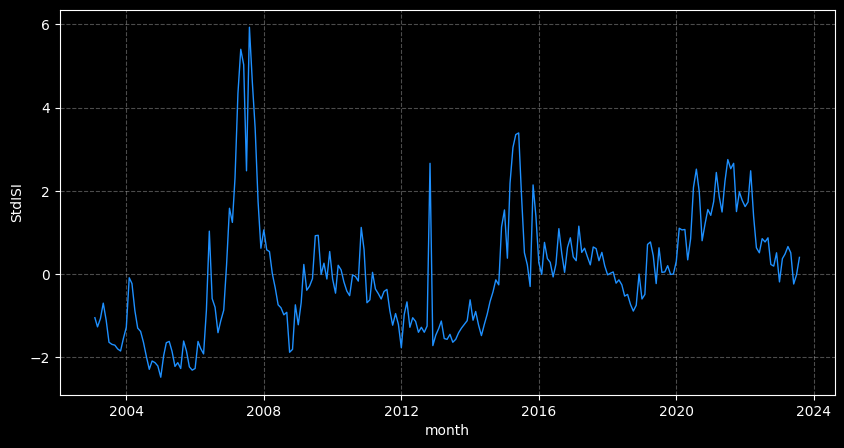

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(analysis_df["month_dt"], analysis_df["StdISI"], color="dodgerblue", linewidth=1)
plt.xlabel("month")
plt.ylabel("StdISI")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 2.3. EDA: Shanghai Return and StdISI

Compare Shanghai monthly returns with standardized investor sentiment.


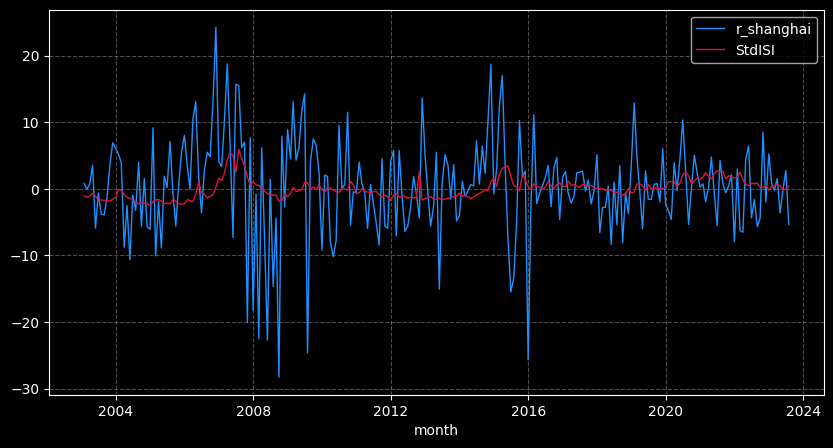

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(analysis_df["month_dt"], analysis_df["r_shanghai"], label="r_shanghai", color="dodgerblue", linewidth=1)
plt.plot(analysis_df["month_dt"], analysis_df["StdISI"], label="StdISI", color="crimson", linewidth=1)
plt.xlabel("month")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 2.4. EDA: Shanghai Return and ISI

Compare Shanghai monthly returns with the original investor sentiment index.


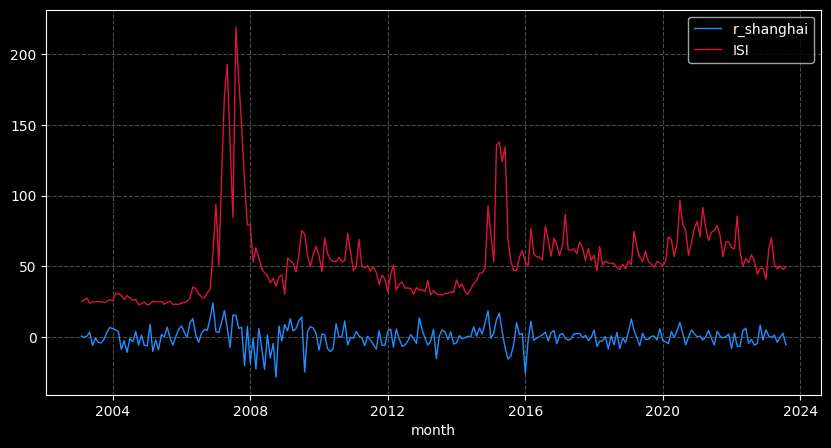

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(analysis_df["month_dt"], analysis_df["r_shanghai"], label="r_shanghai", color="dodgerblue", linewidth=1)
plt.plot(analysis_df["month_dt"], analysis_df["ISI"], label="ISI", color="crimson", linewidth=1)
plt.xlabel("month")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 2.5. EDA: Shanghai Price and ISI

Compare Shanghai index price with the original investor sentiment index.


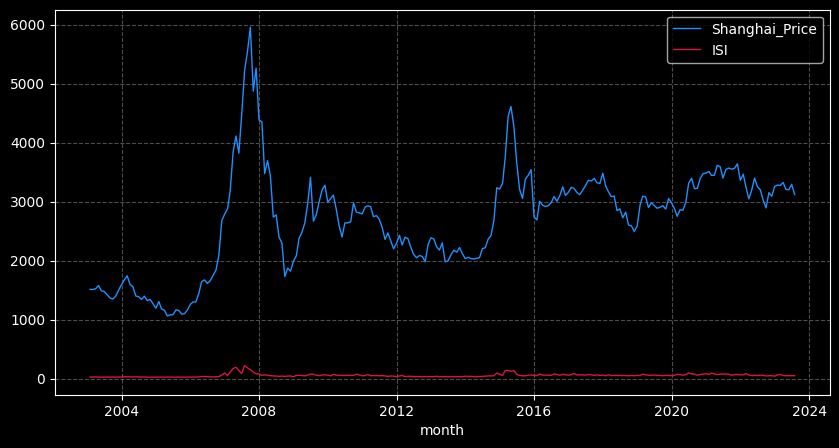

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(analysis_df["month_dt"], analysis_df["shanghai_price"], label="Shanghai_Price", color="dodgerblue", linewidth=1)
plt.plot(analysis_df["month_dt"], analysis_df["ISI"], label="ISI", color="crimson", linewidth=1)
plt.xlabel("month")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 2.6. Correlation Table Function

Define a reusable HTML correlation table with p-values and significance stars.


In [53]:
def correlation_table_html(df, variables, star_level=0.05):
    corr_display = pd.DataFrame("", index=variables, columns=variables)

    for row_var in variables:
        for col_var in variables:
            row_index = variables.index(row_var)
            col_index = variables.index(col_var)

            # Only show the lower triangle.
            if col_index > row_index:
                continue

            if row_var == col_var:
                corr_display.loc[row_var, col_var] = "1.0000"
            else:
                temp = df[[row_var, col_var]].dropna()
                corr, p_value = pearsonr(temp[row_var], temp[col_var])

                star = "*" if p_value < star_level else ""
                corr_display.loc[row_var, col_var] = (
                    f"{corr:.4f}{star}<br>"
                    f"{p_value:.4f}"
                )

    html = corr_display.to_html(escape=False)
    display(HTML(html))

    return corr_display


## 2.7. Correlation: Returns and StdISI

Compute pairwise correlations between market returns and StdISI.


In [54]:
corr_vars_stdisi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "StdISI"
]

corr_stdisi_table = correlation_table_html(
    analysis_df,
    corr_vars_stdisi,
    star_level=0.05
)


,r_shanghai,r_nikkei,r_kospi,r_hangseng,r_singapore,r_sp500,StdISI
r_shanghai,1.0000,,,,,,
r_nikkei,0.3477*0.0000,1.0000,,,,,
r_kospi,0.4113*0.0000,0.6068*0.0000,1.0000,,,,
r_hangseng,0.5592*0.0000,0.4680*0.0000,0.5589*0.0000,1.0000,,,
r_singapore,0.4491*0.0000,0.6292*0.0000,0.6957*0.0000,0.7031*0.0000,1.0000,,
r_sp500,0.3653*0.0000,0.6851*0.0000,0.6855*0.0000,0.5339*0.0000,0.6980*0.0000,1.0000,
StdISI,0.10790.0906,-0.02140.7385,0.02710.6714,-0.01080.8659,0.00020.9972,0.01200.8514,1.0000


## 2.8. Correlation: Returns and ISI

Compute pairwise correlations between market returns and ISI.


In [55]:
corr_vars_isi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "ISI"
]

corr_isi_table = correlation_table_html(
    analysis_df,
    corr_vars_isi,
    star_level=0.05
)


,r_shanghai,r_nikkei,r_kospi,r_hangseng,r_singapore,r_sp500,ISI
r_shanghai,1.0000,,,,,,
r_nikkei,0.3477*0.0000,1.0000,,,,,
r_kospi,0.4113*0.0000,0.6068*0.0000,1.0000,,,,
r_hangseng,0.5592*0.0000,0.4680*0.0000,0.5589*0.0000,1.0000,,,
r_singapore,0.4491*0.0000,0.6292*0.0000,0.6957*0.0000,0.7031*0.0000,1.0000,,
r_sp500,0.3653*0.0000,0.6851*0.0000,0.6855*0.0000,0.5339*0.0000,0.6980*0.0000,1.0000,
ISI,0.1824*0.0040,-0.04360.4955,0.05130.4222,0.05590.3814,0.01130.8593,0.02680.6753,1.0000


## 2.9. EDA: Distribution Diagnostics

Report dissertation-ready descriptive statistics for all extended-model variables, including skewness, excess kurtosis and the Jarque–Bera normality test.


In [56]:
# Distribution diagnostics include the S&P 500 return omitted from the earlier summary table.
eda_vars = ["r_shanghai", "r_nikkei", "r_kospi", "r_hangseng", "r_singapore", "r_sp500", "StdISI"]
eda_labels = {
    "r_shanghai": "Shanghai Composite return", "r_nikkei": "Nikkei 225 return",
    "r_kospi": "KOSPI return", "r_hangseng": "Hang Seng return",
    "r_singapore": "Singapore STI return", "r_sp500": "S&P 500 return",
    "StdISI": "Chinese investor sentiment (StdISI)"
}
eda_rows = []
for variable in eda_vars:
    series = analysis_df[variable].dropna()
    jb = scipy.stats.jarque_bera(series)
    eda_rows.append({
        "Variable": eda_labels[variable], "N": len(series),
        "Mean": series.mean(), "Std. dev.": series.std(ddof=1),
        "Minimum": series.min(), "Maximum": series.max(),
        "Skewness": series.skew(), "Excess kurtosis": series.kurt(),
        "Jarque-Bera": jb.statistic, "JB p-value": jb.pvalue
    })
eda_descriptive_table_extended = pd.DataFrame(eda_rows).set_index("Variable")
display(eda_descriptive_table_extended.round(4))


,N,Mean,Std. dev.,Minimum,Maximum,Skewness,Excess kurtosis,Jarque-Bera,JB p-value
Variable,,,,,,,,,
Shanghai Composite return,247,0.2965,7.3276,-28.2779,24.2526,-0.5576,2.4545,70.9872,0.0
Nikkei 225 return,247,0.5522,5.3323,-27.2162,14.0137,-0.8677,2.5493,93.6023,0.0
KOSPI return,247,0.5923,5.4027,-26.3112,13.3652,-0.7262,2.5492,84.4225,0.0
Hang Seng return,247,0.2776,6.4033,-25.4455,23.6049,-0.3132,2.1365,48.0569,0.0
Singapore STI return,247,0.3835,4.8291,-27.3640,19.3002,-1.0150,6.2247,421.7496,0.0
S&P 500 return,247,0.6727,4.2761,-18.5619,11.9421,-0.8280,1.9670,65.1585,0.0
Chinese investor sentiment (StdISI),247,0.0050,1.4646,-2.4800,5.9300,1.0085,1.7107,69.4473,0.0


## 2.10. EDA: Correlation Heatmap

Visualise the extended-model correlation matrix with thesis-ready labels.


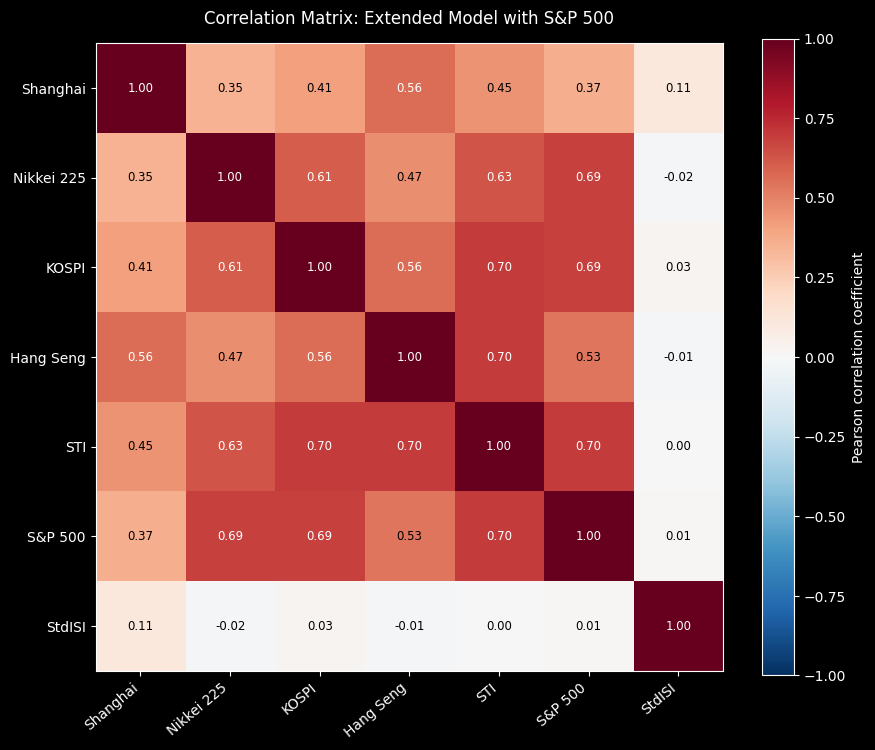

In [57]:
corr_matrix = analysis_df[eda_vars].corr()
short_labels = ["Shanghai", "Nikkei 225", "KOSPI", "Hang Seng", "STI", "S&P 500", "StdISI"]
fig, ax = plt.subplots(figsize=(9, 7.5))
image = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(short_labels)), short_labels, rotation=40, ha="right")
ax.set_yticks(range(len(short_labels)), short_labels)
for row in range(len(short_labels)):
    for column in range(len(short_labels)):
        value = corr_matrix.iloc[row, column]
        ax.text(column, row, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.55 else "black", fontsize=8.5)
ax.set_title("Correlation Matrix: Extended Model with S&P 500", pad=14)
fig.colorbar(image, ax=ax, label="Pearson correlation coefficient")
fig.tight_layout()
plt.show()


## 2.11. EDA: Return Dynamics and Distributions

Plot all six monthly return series and use boxplots to identify heavy tails and extreme observations.


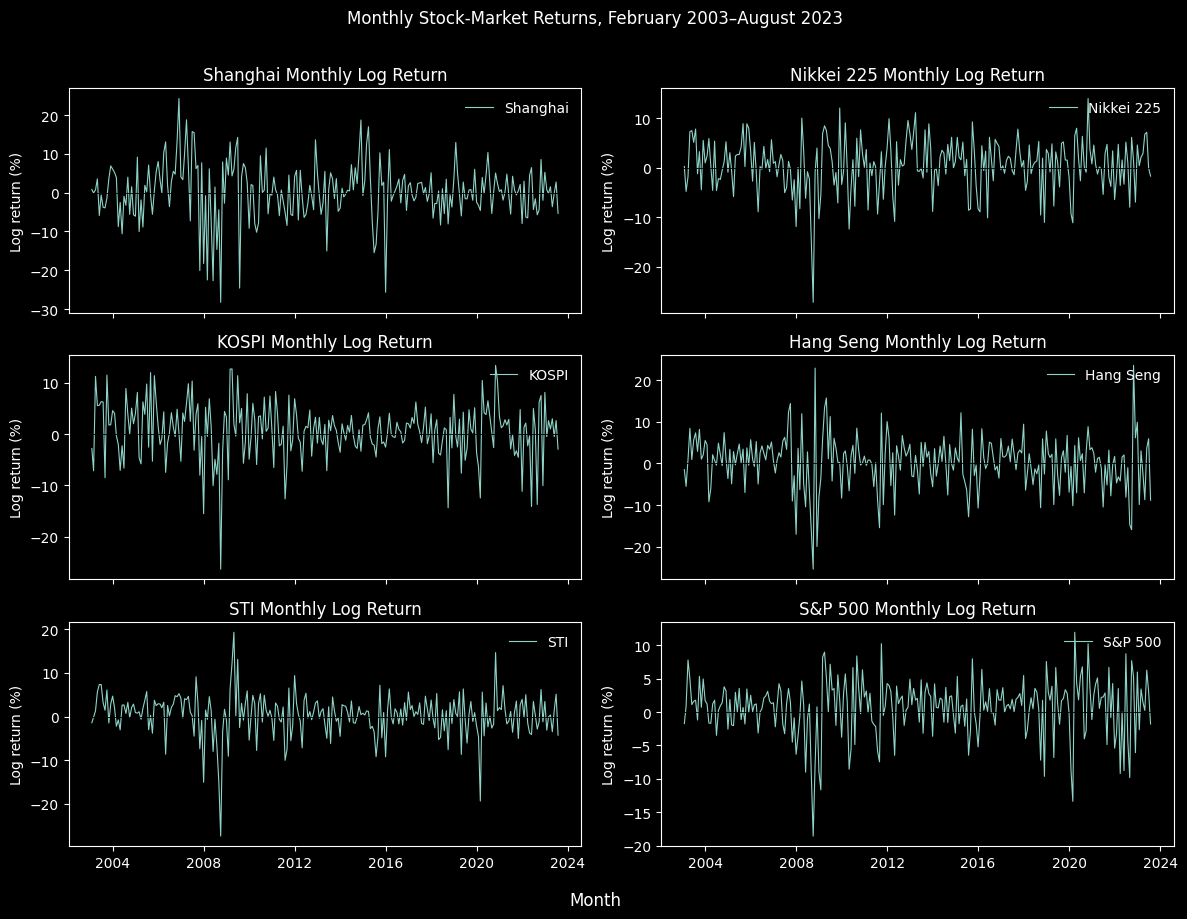

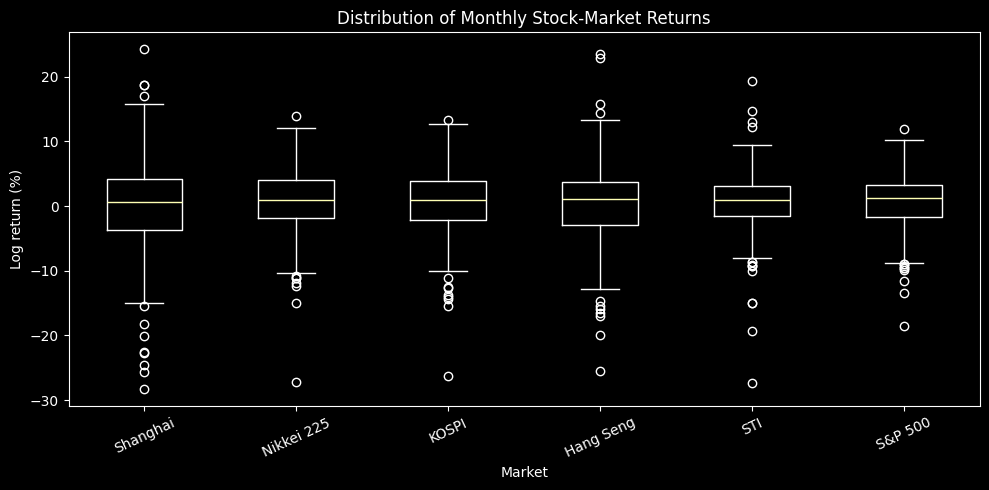

In [58]:
return_plot_vars = eda_vars[:-1]
return_plot_labels = short_labels[:-1]
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for ax, variable, label in zip(axes.ravel(), return_plot_vars, return_plot_labels):
    ax.plot(analysis_df["month_dt"], analysis_df[variable], linewidth=0.8, label=label)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(f"{label} Monthly Log Return")
    ax.set_ylabel("Log return (%)")
    ax.legend(frameon=False, loc="upper right")
fig.suptitle("Monthly Stock-Market Returns, February 2003–August 2023", y=1.01)
fig.supxlabel("Month")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([analysis_df[v].dropna() for v in return_plot_vars], tick_labels=return_plot_labels, showfliers=True)
ax.set_title("Distribution of Monthly Stock-Market Returns")
ax.set_xlabel("Market")
ax.set_ylabel("Log return (%)")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()


## 2.12. VAR Lag Selection: ISI, Max Lag 4

Select lag order for the VAR model using returns and ISI with maximum lag 4.


In [59]:
# ISI VAR lag-order selection with maximum lag 4.
var_vars_isi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "ISI"
]

var_data_isi = analysis_df[var_vars_isi].dropna().copy()
var_model_isi = VAR(var_data_isi)

lag_order_isi_4 = var_model_isi.select_order(maxlags=4)
lag_order_isi_4.summary()


,AIC,BIC,FPE,HQIC
0,23.80,23.90,2.165e+10,23.84
1,22.63*,23.43*,6.727e+09*,22.95*
2,22.63,24.14,6.767e+09,23.24
3,22.70,24.91,7.208e+09,23.59
4,22.64,25.56,6.859e+09,23.82


## 2.13. VAR Lag Selection: ISI, Max Lag 6

Repeat lag-order selection for the ISI model with maximum lag 6.


In [60]:
# ISI VAR lag-order selection with maximum lag 6.
var_vars_isi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "ISI"
]

var_data_isi = analysis_df[var_vars_isi].dropna().copy()
var_model_isi = VAR(var_data_isi)

lag_order_isi_6 = var_model_isi.select_order(maxlags=6)
lag_order_isi_6.summary()


,AIC,BIC,FPE,HQIC
0,23.80,23.90,2.163e+10,23.84
1,22.64*,23.45*,6.805e+09*,22.97*
2,22.65,24.16,6.848e+09,23.26
3,22.71,24.94,7.325e+09,23.61
4,22.65,25.59,6.939e+09,23.83
5,22.73,26.38,7.566e+09,24.20
6,22.88,27.23,8.900e+09,24.64


## 2.14. VAR Lag Selection: StdISI, Max Lag 6

Select lag order for the VAR model using returns and StdISI with maximum lag 6.


In [61]:
# StdISI VAR lag-order selection with maximum lag 6.
var_vars_stdisi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "StdISI"
]

var_data_stdisi = analysis_df[var_vars_stdisi].dropna().copy()
var_model_stdisi = VAR(var_data_stdisi)

lag_order_stdisi_6 = var_model_stdisi.select_order(maxlags=6)
lag_order_stdisi_6.summary()


,AIC,BIC,FPE,HQIC
0,17.91,18.01,5.978e+07,17.95
1,16.42*,17.23*,1.348e+07*,16.74*
2,16.42,17.93,1.349e+07,17.03
3,16.54,18.77,1.532e+07,17.44
4,16.47,19.40,1.432e+07,17.65
5,16.54,20.18,1.548e+07,18.01
6,16.69,21.04,1.814e+07,18.44


# 3. Alternative Sentiment Measure: Extended StdISI VAR(2)

Estimate the alternative extended VAR(2) specification using StdISI and the S&P 500 return.


## 3.1. Alternative Extended VAR(2) Model with StdISI

Estimate the VAR model with two lags using market returns and StdISI.


In [62]:
# Estimate the VAR(2) model with StdISI.
var_vars_stdisi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "StdISI"
]

var_data_stdisi = analysis_df[var_vars_stdisi].dropna().copy()
var_model_stdisi = VAR(var_data_stdisi)

# fit(2) includes lags 1 and 2.
var_results_stdisi_lag2 = var_model_stdisi.fit(2)

print(var_results_stdisi_lag2.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Jul, 2026
Time:                     21:20:04
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    17.9114
Nobs:                     245.000    HQIC:                   17.0151
Log likelihood:          -4338.81    FPE:                1.34153e+07
AIC:                      16.4108    Det(Omega_mle):     8.85010e+06
--------------------------------------------------------------------
Results for equation r_shanghai
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.363876         0.477731            0.762           0.446
L1.r_shanghai          0.102867         0.080148            1.283           0.199
L1.r_nikkei           -0.057032         0.128344   

## 3.2. Full VAR Coefficient Table

Create a complete coefficient table for the VAR(2) model.


In [63]:
# Complete coefficient table for the VAR(2) model.
params = var_results_stdisi_lag2.params
stderr = var_results_stdisi_lag2.stderr
zvalues = var_results_stdisi_lag2.tvalues
pvalues = var_results_stdisi_lag2.pvalues

z_crit = norm.ppf(0.975)

base_variables = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "StdISI"
]

ordered_parameters = []
for base_var in base_variables:
    for lag_number in range(1, 3):
        ordered_parameters.append(f"L{lag_number}.{base_var}")
ordered_parameters.append("const")

rows = []

for equation in params.columns:
    for variable in ordered_parameters:
        if variable not in params.index:
            continue

        coef = params.loc[variable, equation]
        se = stderr.loc[variable, equation]
        z = zvalues.loc[variable, equation]
        p = pvalues.loc[variable, equation]
        ci_lower = coef - z_crit * se
        ci_upper = coef + z_crit * se

        if variable == "const":
            lag = "const"
            variable_name = "const"
        else:
            lag, variable_name = variable.split(".", 1)

        rows.append({
            "Equation": equation,
            "Variable": variable_name,
            "Lag": lag,
            "Coefficient": coef,
            "Std. err.": se,
            "z": z,
            "P>|z|": p,
            "95% CI lower": ci_lower,
            "95% CI upper": ci_upper
        })

var_stdisi_lag2_full_table = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(var_stdisi_lag2_full_table)


,Equation,Variable,Lag,Coefficient,Std. err.,z,P>|z|,95% CI lower,95% CI upper
0,r_shanghai,r_shanghai,L1,0.102867,0.080148,1.283457,1.993319e-01,-0.054221,0.259955
1,r_shanghai,r_shanghai,L2,0.131591,0.089115,1.476644,1.397710e-01,-0.043071,0.306253
2,r_shanghai,r_nikkei,L1,-0.057032,0.128344,-0.444366,6.567783e-01,-0.308582,0.194519
3,r_shanghai,r_nikkei,L2,-0.137393,0.130994,-1.048849,2.942474e-01,-0.394137,0.119351
4,r_shanghai,r_kospi,L1,0.053680,0.135711,0.395544,6.924414e-01,-0.212309,0.319668
5,r_shanghai,r_kospi,L2,0.217455,0.134466,1.617176,1.058403e-01,-0.046093,0.481004
6,r_shanghai,r_hangseng,L1,-0.020332,0.116237,-0.174914,8.611469e-01,-0.248152,0.207489
7,r_shanghai,r_hangseng,L2,-0.034987,0.111988,-0.312416,7.547241e-01,-0.254480,0.184506
8,r_shanghai,r_singapore,L1,0.058886,0.176458,0.333713,7.385962e-01,-0.286965,0.404738
9,r_shanghai,r_singapore,L2,0.345910,0.172174,2.009076,4.452908e-02,0.008456,0.683364


## 3.3. Key VAR(2) Relationships

Display the two directions of interest separately. A p-value below 0.05 indicates statistical significance.


In [64]:
# Direction 1: Does investor sentiment predict subsequent market returns?
sentiment_to_returns = var_stdisi_lag2_full_table.loc[
    (var_stdisi_lag2_full_table["Variable"] == "StdISI")
    & (var_stdisi_lag2_full_table["Equation"] != "StdISI"),
    ["Equation", "Coefficient", "P>|z|", "95% CI lower", "95% CI upper"]
].copy()
sentiment_to_returns["Significant at 5%"] = sentiment_to_returns["P>|z|"] < 0.05

print("Direction 1: StdISI -> market returns")
display(sentiment_to_returns)

# Direction 2: Do market returns predict subsequent investor sentiment?
returns_to_sentiment = var_stdisi_lag2_full_table.loc[
    (var_stdisi_lag2_full_table["Equation"] == "StdISI")
    & (~var_stdisi_lag2_full_table["Variable"].isin(["StdISI", "const"])),
    ["Variable", "Coefficient", "P>|z|", "95% CI lower", "95% CI upper"]
].copy()
returns_to_sentiment["Significant at 5%"] = returns_to_sentiment["P>|z|"] < 0.05

print("Direction 2: Market returns -> StdISI")
display(returns_to_sentiment)


Direction 1: StdISI -> market returns


,Equation,Coefficient,P>|z|,95% CI lower,95% CI upper,Significant at 5%
12,r_shanghai,-0.584052,0.435076,-2.050638,0.882533,False
13,r_shanghai,0.303067,0.665684,-1.071684,1.677818,False
27,r_nikkei,-0.181997,0.738178,-1.249128,0.885134,False
28,r_nikkei,-0.245558,0.630420,-1.245868,0.754751,False
42,r_kospi,0.574808,0.291981,-0.494293,1.643909,False
43,r_kospi,-0.692380,0.175698,-1.694536,0.309776,False
57,r_hangseng,-0.686812,0.285949,-1.948352,0.574728,False
58,r_hangseng,0.264216,0.661448,-0.918329,1.446761,False
72,r_singapore,-0.037118,0.939162,-0.990290,0.916055,False
73,r_singapore,-0.290549,0.523896,-1.184036,0.602938,False


Direction 2: Market returns -> StdISI


,Variable,Coefficient,P>|z|,95% CI lower,95% CI upper,Significant at 5%
90,r_shanghai,0.061861,5.338458e-19,0.048245,0.075476,True
91,r_shanghai,0.002691,7.275196e-01,-0.012447,0.017830,False
92,r_nikkei,-0.019979,7.248570e-02,-0.041782,0.001823,False
93,r_nikkei,-0.016219,1.531425e-01,-0.038472,0.006034,False
94,r_kospi,-0.013060,2.668516e-01,-0.036115,0.009994,False
95,r_kospi,0.011327,3.311239e-01,-0.011516,0.034169,False
96,r_hangseng,-0.008940,3.748783e-01,-0.028686,0.010806,False
97,r_hangseng,-0.003836,6.927079e-01,-0.022860,0.015188,False
98,r_singapore,-0.004479,7.696450e-01,-0.034455,0.025497,False
99,r_singapore,0.008014,5.912301e-01,-0.021234,0.037263,False


## 3.4. VAR Stability Test

Check whether the estimated VAR model satisfies the stability condition.


In [65]:
# Stability test using companion-matrix eigenvalues.
# The VAR is stable when all eigenvalue moduli are less than 1.
eigenvalues = 1 / var_results_stdisi_lag2.roots

stability_table = pd.DataFrame({
    "Eigenvalue": eigenvalues,
    "Modulus": np.abs(eigenvalues)
})

stability_table = stability_table.sort_values(
    by="Modulus",
    ascending=False
).reset_index(drop=True)

display(stability_table)

if np.all(stability_table["Modulus"] < 1):
    print("All eigenvalue moduli are less than 1.")
    print("VAR satisfies stability condition.")
else:
    print("At least one eigenvalue modulus is greater than or equal to 1.")
    print("VAR does not satisfy stability condition.")


,Eigenvalue,Modulus
0,0.881455+0.000000j,0.881455
1,-0.109321-0.561954j,0.572488
2,-0.109321+0.561954j,0.572488
3,0.461261+0.000000j,0.461261
4,-0.435087-0.048701j,0.437804
5,-0.435087+0.048701j,0.437804
6,0.366820+0.000000j,0.366820
7,0.062630+0.287759j,0.294496
8,0.062630-0.287759j,0.294496
9,-0.290100-0.000000j,0.290100


All eigenvalue moduli are less than 1.
VAR satisfies stability condition.


## 3.5. Granger Causality Tests

Run Wald tests for Granger causality among the VAR variables.


In [66]:
# Granger causality Wald tests using statsmodels.
var_names = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "StdISI"
]

granger_rows = []

for equation in var_names:
    excluded_vars = [var for var in var_names if var != equation]

    # Test each excluded variable one by one.
    for excluded in excluded_vars:
        test_result = var_results_stdisi_lag2.test_causality(
            caused=equation,
            causing=excluded,
            kind="wald"
        )

        granger_rows.append({
            "Equation": equation,
            "Excluded": excluded,
            "chi2": test_result.test_statistic,
            "df": test_result.df,
            "Prob > chi2": test_result.pvalue
        })

    # Test all other variables jointly.
    test_all = var_results_stdisi_lag2.test_causality(
        caused=equation,
        causing=excluded_vars,
        kind="wald"
    )

    granger_rows.append({
        "Equation": equation,
        "Excluded": "ALL",
        "chi2": test_all.test_statistic,
        "df": test_all.df,
        "Prob > chi2": test_all.pvalue
    })

granger_table = pd.DataFrame(granger_rows)

granger_table_formatted = granger_table.copy()
granger_table_formatted["chi2"] = granger_table_formatted["chi2"].map(lambda x: f"{x:.4f}")
granger_table_formatted["Prob > chi2"] = granger_table_formatted["Prob > chi2"].map(lambda x: f"{x:.3f}")

display(granger_table_formatted)


,Equation,Excluded,chi2,df,Prob > chi2
0,r_shanghai,r_nikkei,1.2993,2,0.522
1,r_shanghai,r_kospi,2.6974,2,0.260
2,r_shanghai,r_hangseng,0.1183,2,0.943
3,r_shanghai,r_singapore,4.1169,2,0.128
4,r_shanghai,r_sp500,6.0160,2,0.049
5,r_shanghai,StdISI,0.9333,2,0.627
6,r_shanghai,ALL,13.9454,12,0.304
7,r_nikkei,r_shanghai,2.8531,2,0.240
8,r_nikkei,r_kospi,2.7353,2,0.255
9,r_nikkei,r_hangseng,0.7384,2,0.691


# 4. Lag-Length Robustness Check: Extended StdISI VAR(4)

Assess the lag-length sensitivity of the alternative extended StdISI specification using four lags.


## 4.1. VAR(4) Model with StdISI

Estimate the VAR model with four lags using market returns and StdISI.


In [67]:
# Estimate the VAR(4) model with StdISI.
var_vars_stdisi = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "StdISI"
]

var_data_stdisi = analysis_df[var_vars_stdisi].dropna().copy()
var_model_stdisi = VAR(var_data_stdisi)

# fit(4) includes lags 1 through 4.
var_results_stdisi_lag4 = var_model_stdisi.fit(4)

print(var_results_stdisi_lag4.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Jul, 2026
Time:                     21:20:05
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    19.3800
Nobs:                     243.000    HQIC:                   17.6373
Log likelihood:          -4210.74    FPE:                1.42171e+07
AIC:                      16.4620    Det(Omega_mle):     6.45762e+06
--------------------------------------------------------------------
Results for equation r_shanghai
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.257748         0.484030            0.533           0.594
L1.r_shanghai          0.086242         0.080234            1.075           0.282
L1.r_nikkei           -0.105128         0.129446   

## 4.2. Full VAR(4) Coefficient Table

Create a complete coefficient table for the VAR(4) model.


In [68]:
# Complete coefficient table for the VAR(4) model.
params = var_results_stdisi_lag4.params
stderr = var_results_stdisi_lag4.stderr
zvalues = var_results_stdisi_lag4.tvalues
pvalues = var_results_stdisi_lag4.pvalues

z_crit = norm.ppf(0.975)

base_variables = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "StdISI"
]

ordered_parameters = []
for base_var in base_variables:
    for lag_number in range(1, 5):
        ordered_parameters.append(f"L{lag_number}.{base_var}")
ordered_parameters.append("const")

rows = []

for equation in params.columns:
    for variable in ordered_parameters:
        if variable not in params.index:
            continue

        coef = params.loc[variable, equation]
        se = stderr.loc[variable, equation]
        z = zvalues.loc[variable, equation]
        p = pvalues.loc[variable, equation]
        ci_lower = coef - z_crit * se
        ci_upper = coef + z_crit * se

        if variable == "const":
            lag = "const"
            variable_name = "const"
        else:
            lag, variable_name = variable.split(".", 1)

        rows.append({
            "Equation": equation,
            "Variable": variable_name,
            "Lag": lag,
            "Coefficient": coef,
            "Std. err.": se,
            "z": z,
            "P>|z|": p,
            "95% CI lower": ci_lower,
            "95% CI upper": ci_upper
        })

var_stdisi_lag4_full_table = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(var_stdisi_lag4_full_table)


,Equation,Variable,Lag,Coefficient,Std. err.,z,P>|z|,95% CI lower,95% CI upper
0,r_shanghai,r_shanghai,L1,0.086242,0.080234,1.074882,2.824277e-01,-0.071014,0.243497
1,r_shanghai,r_shanghai,L2,0.158075,0.095495,1.655321,9.785940e-02,-0.029092,0.345241
2,r_shanghai,r_shanghai,L3,0.062206,0.094219,0.660223,5.091108e-01,-0.122460,0.246871
3,r_shanghai,r_shanghai,L4,0.359563,0.089675,4.009621,6.081633e-05,0.183803,0.535322
4,r_shanghai,r_nikkei,L1,-0.105128,0.129446,-0.812136,4.167133e-01,-0.358838,0.148582
5,r_shanghai,r_nikkei,L2,-0.141110,0.131971,-1.069251,2.849565e-01,-0.399768,0.117548
6,r_shanghai,r_nikkei,L3,-0.084775,0.133341,-0.635776,5.249227e-01,-0.346119,0.176569
7,r_shanghai,r_nikkei,L4,0.023417,0.134127,0.174587,8.614042e-01,-0.239467,0.286301
8,r_shanghai,r_kospi,L1,0.075436,0.141891,0.531647,5.949707e-01,-0.202665,0.353536
9,r_shanghai,r_kospi,L2,0.268827,0.138929,1.934996,5.299076e-02,-0.003469,0.541122


## 4.3. VAR(4) Stability Test

Check whether the VAR(4) model satisfies the stability condition.


In [69]:
# Stability test using companion-matrix eigenvalues.
# The VAR is stable when all eigenvalue moduli are less than 1.
eigenvalues_lag4 = 1 / var_results_stdisi_lag4.roots

stability_table_lag4 = pd.DataFrame({
    "Eigenvalue": eigenvalues_lag4,
    "Modulus": np.abs(eigenvalues_lag4)
})

stability_table_lag4 = stability_table_lag4.sort_values(
    by="Modulus",
    ascending=False
).reset_index(drop=True)

display(stability_table_lag4)

if np.all(stability_table_lag4["Modulus"] < 1):
    print("All eigenvalue moduli are less than 1.")
    print("VAR(4) satisfies stability condition.")
else:
    print("At least one eigenvalue modulus is greater than or equal to 1.")
    print("VAR(4) does not satisfy stability condition.")


,Eigenvalue,Modulus
0,0.862759+0.000000j,0.862759
1,-0.400203-0.679722j,0.788786
2,-0.400203+0.679722j,0.788786
3,0.755152+0.000000j,0.755152
4,0.006163-0.715992j,0.716018
5,0.006163+0.715992j,0.716018
6,0.062358-0.692507j,0.695309
7,0.062358+0.692507j,0.695309
8,0.635217+0.243147j,0.680163
9,0.635217-0.243147j,0.680163


All eigenvalue moduli are less than 1.
VAR(4) satisfies stability condition.


## 4.4. VAR(4) Granger Causality Tests

Run Wald tests for Granger causality using the VAR(4) model.


In [70]:
# Granger causality Wald tests using the VAR(4) model.
var_names = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "StdISI"
]

granger_lag4_rows = []

for equation in var_names:
    excluded_vars = [var for var in var_names if var != equation]

    # Test each excluded variable one by one.
    for excluded in excluded_vars:
        test_result = var_results_stdisi_lag4.test_causality(
            caused=equation,
            causing=excluded,
            kind="wald"
        )

        granger_lag4_rows.append({
            "Equation": equation,
            "Excluded": excluded,
            "chi2": test_result.test_statistic,
            "df": test_result.df,
            "Prob > chi2": test_result.pvalue
        })

    # Test all other variables jointly.
    test_all = var_results_stdisi_lag4.test_causality(
        caused=equation,
        causing=excluded_vars,
        kind="wald"
    )

    granger_lag4_rows.append({
        "Equation": equation,
        "Excluded": "ALL",
        "chi2": test_all.test_statistic,
        "df": test_all.df,
        "Prob > chi2": test_all.pvalue
    })

granger_lag4_table = pd.DataFrame(granger_lag4_rows)

granger_lag4_table_formatted = granger_lag4_table.copy()
granger_lag4_table_formatted["chi2"] = granger_lag4_table_formatted["chi2"].map(lambda x: f"{x:.4f}")
granger_lag4_table_formatted["Prob > chi2"] = granger_lag4_table_formatted["Prob > chi2"].map(lambda x: f"{x:.3f}")

display(granger_lag4_table_formatted)


,Equation,Excluded,chi2,df,Prob > chi2
0,r_shanghai,r_nikkei,2.1788,4,0.703
1,r_shanghai,r_kospi,13.6335,4,0.009
2,r_shanghai,r_hangseng,1.3608,4,0.851
3,r_shanghai,r_singapore,5.4232,4,0.247
4,r_shanghai,r_sp500,6.7487,4,0.150
5,r_shanghai,StdISI,5.7506,4,0.219
6,r_shanghai,ALL,34.0207,24,0.084
7,r_nikkei,r_shanghai,11.2439,4,0.024
8,r_nikkei,r_kospi,11.6152,4,0.020
9,r_nikkei,r_hangseng,3.9335,4,0.415


# 5. PCA Sentiment Index Construction

Construct an alternative investor sentiment index from the six sentiment proxy variables.


## 5.1. Descriptive Statistics and Standardisation

Report descriptive statistics for the six sentiment proxies, then standardise them for PCA.


In [71]:
# Descriptive statistics for the six sentiment proxies used in PCA.
sentiment_pca_vars = ["DCEF", "RIPO", "NIPO", "NA", "TURN", "CCI"]

summary_sentiment = pd.DataFrame({
    "N": master_df[sentiment_pca_vars].count(),
    "Mean": master_df[sentiment_pca_vars].mean(),
    "Std. dev.": master_df[sentiment_pca_vars].std(ddof=1),
    "Minimum": master_df[sentiment_pca_vars].min(),
    "Maximum": master_df[sentiment_pca_vars].max()
})

summary_sentiment.index.name = "Variable"
display(summary_sentiment.round(4))


,N,Mean,Std. dev.,Minimum,Maximum
Variable,,,,,
DCEF,248,-0.1211,0.1301,-0.3321,0.4414
RIPO,248,0.6191,0.6737,-0.0521,6.2674
NIPO,248,17.3185,15.8620,0.0000,82.0000
NA,248,40.2921,41.6088,2.3000,297.4700
TURN,248,0.2562,0.1226,0.0852,0.8247
CCI,248,104.0109,11.1870,85.5000,127.0000


In [72]:
# Sentiment variables used for PCA.
sentiment_pca_vars = ["DCEF", "RIPO", "NIPO", "NA", "TURN", "CCI"]

# Use the full merged monthly dataset for PCA because these sentiment variables
# do not lose the first return observation.
pca_df = master_df[["month"] + sentiment_pca_vars].copy()

for col in sentiment_pca_vars:
    pca_df[f"z_{col}"] = (
        pca_df[col] - pca_df[col].mean()
    ) / pca_df[col].std(ddof=1)

z_sentiment_vars = [f"z_{col}" for col in sentiment_pca_vars]

print(f"PCA observations: {len(pca_df)}")
print("Standardized variables:")
print(z_sentiment_vars)

pca_df[["month"] + z_sentiment_vars].head()


PCA observations: 248
Standardized variables:
['z_DCEF', 'z_RIPO', 'z_NIPO', 'z_NA', 'z_TURN', 'z_CCI']


,month,z_DCEF,z_RIPO,z_NIPO,z_NA,z_TURN,z_CCI
0,2003-01,0.135937,0.424325,-0.776608,-0.872941,-1.230155,-0.582007
1,2003-02,0.072138,0.222611,-0.902696,-0.899858,-0.517233,-0.564129
2,2003-03,0.207424,0.094962,-0.713564,-0.890005,-1.006653,-0.555190
3,2003-04,-0.144628,0.840370,-0.776608,-0.831604,-1.096380,-0.573068
4,2003-05,-0.523585,0.657803,-0.965740,-0.867173,0.517891,-1.368638


## 5.2. PCA for Sentiment Variables

Run PCA using the standardized sentiment variables and report eigenvalues, explained variance, and loadings.


In [73]:
# PCA on standardized sentiment variables.
X_pca = pca_df[z_sentiment_vars].dropna().copy()

pca_model = PCA()
pca_scores = pca_model.fit_transform(X_pca)

component_names = [f"Comp{i}" for i in range(1, len(z_sentiment_vars) + 1)]

eigenvalues = pca_model.explained_variance_
proportion = pca_model.explained_variance_ratio_
cumulative = np.cumsum(proportion)
difference = np.r_[eigenvalues[:-1] - eigenvalues[1:], np.nan]

pca_summary = pd.DataFrame({
    "Component": component_names,
    "Eigenvalue": eigenvalues,
    "Difference": difference,
    "Proportion": proportion,
    "Cumulative": cumulative
})

loadings = pd.DataFrame(
    pca_model.components_.T,
    index=z_sentiment_vars,
    columns=component_names
)

print(f"Number of obs: {len(X_pca)}")
print(f"Number of components: {len(component_names)}")
print(f"Trace: {eigenvalues.sum():.4f}")

print("\nPCA summary:")
display(pca_summary)

print("\nPCA loadings:")
display(loadings)


Number of obs: 248
Number of components: 6
Trace: 6.0000

PCA summary:


,Component,Eigenvalue,Difference,Proportion,Cumulative
0,Comp1,2.011522,0.386965,0.335254,0.335254
1,Comp2,1.624557,0.753347,0.270759,0.606013
2,Comp3,0.871209,0.157553,0.145202,0.751215
3,Comp4,0.713657,0.291885,0.118943,0.870157
4,Comp5,0.421772,0.064488,0.070295,0.940453
5,Comp6,0.357284,NaN,0.059547,1.000000



PCA loadings:


,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6
z_DCEF,0.341958,-0.511647,-0.378379,-0.254048,-0.569954,-0.297866
z_RIPO,0.382240,0.288762,0.590574,-0.570780,-0.005691,-0.309692
z_NIPO,0.492592,-0.380654,-0.175388,-0.148589,0.726318,0.179107
z_NA,0.519818,0.377823,-0.109996,0.061359,-0.335532,0.677195
z_TURN,0.325851,0.512176,-0.420775,0.343762,0.154014,-0.559064
z_CCI,0.343398,-0.323824,0.536786,0.682388,-0.106211,-0.110190


## 5.3. Scree Plot

Plot PCA eigenvalues and add a reference line at eigenvalue 1.


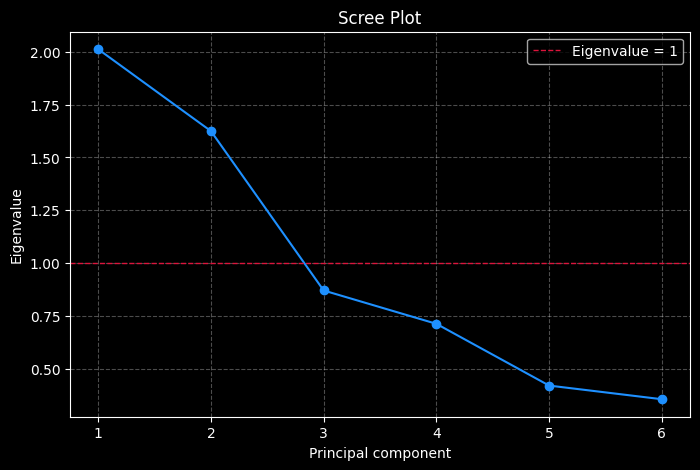

In [74]:
# Scree plot for PCA eigenvalues.
component_numbers = np.arange(1, len(eigenvalues) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    component_numbers,
    eigenvalues,
    marker="o",
    color="dodgerblue",
    linewidth=1.5
)

plt.axhline(
    y=1,
    color="crimson",
    linestyle="--",
    linewidth=1,
    label="Eigenvalue = 1"
)

plt.xticks(component_numbers)
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()


## 5.4. PCA Loadings

Display the PCA loading matrix for the standardized sentiment variables.


In [75]:
# Display PCA loadings separately.
loadings


,Comp1,Comp2,Comp3,Comp4,Comp5,Comp6
z_DCEF,0.341958,-0.511647,-0.378379,-0.254048,-0.569954,-0.297866
z_RIPO,0.382240,0.288762,0.590574,-0.570780,-0.005691,-0.309692
z_NIPO,0.492592,-0.380654,-0.175388,-0.148589,0.726318,0.179107
z_NA,0.519818,0.377823,-0.109996,0.061359,-0.335532,0.677195
z_TURN,0.325851,0.512176,-0.420775,0.343762,0.154014,-0.559064
z_CCI,0.343398,-0.323824,0.536786,0.682388,-0.106211,-0.110190


## 5.5. Generate PCA1 and PCA2

Create the first two principal component score variables.


In [76]:
# Recreate raw PCA results so repeated execution always gives the same signs.
raw_pca_scores = pca_model.transform(X_pca)
raw_loadings = pd.DataFrame(
    pca_model.components_.T,
    index=z_sentiment_vars,
    columns=component_names
)

# Use positive z_DCEF loadings as the fixed orientation for PCA1 and PCA2.
comp1_sign = 1 if raw_loadings.loc["z_DCEF", "Comp1"] >= 0 else -1
comp2_sign = 1 if raw_loadings.loc["z_DCEF", "Comp2"] >= 0 else -1

loadings = raw_loadings.copy()
loadings["Comp1"] = comp1_sign * raw_loadings["Comp1"]
loadings["Comp2"] = comp2_sign * raw_loadings["Comp2"]

pca_df["pca1"] = comp1_sign * raw_pca_scores[:, 0]
pca_df["pca2"] = comp2_sign * raw_pca_scores[:, 1]

pca_df[["month", "pca1", "pca2"]].head()


,month,pca1,pca2
0,2003-01,-1.228350,0.422810
1,2003-02,-1.164926,0.051236
2,2003-03,-1.225578,0.479150
3,2003-04,-1.097114,0.077882
4,2003-05,-1.155325,-1.206262


## 5.6. Construct Final Sentiment Index

Construct the final sentiment index using the first two PCA components weighted by their explained variance shares.


In [77]:
# Recreate deterministically aligned PCA1 and PCA2 if this cell is run separately.
raw_pca_scores = pca_model.transform(X_pca)
comp1_sign = 1 if pca_model.components_[0, z_sentiment_vars.index("z_DCEF")] >= 0 else -1
comp2_sign = 1 if pca_model.components_[1, z_sentiment_vars.index("z_DCEF")] >= 0 else -1
pca_df["pca1"] = comp1_sign * raw_pca_scores[:, 0]
pca_df["pca2"] = comp2_sign * raw_pca_scores[:, 1]

# Construct final sentiment index using PCA1 and PCA2.
pca1_weight = proportion[0]
pca2_weight = proportion[1]
total_weight = pca1_weight + pca2_weight

pca_df["sen"] = (
    (pca1_weight / total_weight) * pca_df["pca1"]
    + (pca2_weight / total_weight) * pca_df["pca2"]
)

# Remove previous PCA columns so this cell can be run repeatedly without suffixes.
analysis_df = analysis_df.drop(
    columns=[
        "pca1", "pca2", "sen",
        "pca1_x", "pca1_y", "pca2_x", "pca2_y",
        "sen_x", "sen_y"
    ],
    errors="ignore"
)

analysis_df = analysis_df.merge(
    pca_df[["month", "pca1", "pca2", "sen"]],
    on="month",
    how="left"
)

print(f"PCA1 weight: {pca1_weight / total_weight:.4f}")
print(f"PCA2 weight: {pca2_weight / total_weight:.4f}")

analysis_df[["month", "pca1", "pca2", "sen"]].head()


PCA1 weight: 0.5532
PCA2 weight: 0.4468


,month,pca1,pca2,sen
0,2003-02,-1.164926,0.051236,-0.621559
1,2003-03,-1.225578,0.479150,-0.463925
2,2003-04,-1.097114,0.077882,-0.572140
3,2003-05,-1.155325,-1.206262,-1.178083
4,2003-06,-1.386193,-0.853339,-1.148120


## 5.7. Descriptive Statistics of Sentiment Indices

Summarise StdISI and the PCA-constructed sentiment index using the common return-analysis sample.


In [78]:
# Descriptive statistics for the original and PCA-constructed sentiment indices.
sentiment_index_vars = ["StdISI", "sen"]

sentiment_index_summary = pd.DataFrame({
    "N": analysis_df[sentiment_index_vars].count(),
    "Mean": analysis_df[sentiment_index_vars].mean(),
    "Std. dev.": analysis_df[sentiment_index_vars].std(ddof=1),
    "Minimum": analysis_df[sentiment_index_vars].min(),
    "Maximum": analysis_df[sentiment_index_vars].max()
})

sentiment_index_summary.index.name = "Variable"
display(sentiment_index_summary.round(4))


,N,Mean,Std. dev.,Minimum,Maximum
Variable,,,,,
StdISI,247,0.005,1.4646,-2.4800,5.9300
sen,247,0.002,0.9710,-1.7175,2.9189


## 5.8. Stationarity Test for Constructed Sentiment Index

Apply the ADF test to the PCA-constructed sentiment index using zero lags, consistent with the Stata `dfuller sen` specification.


In [79]:
# ADF test for sen with zero lags, matching Stata: dfuller sen.
sen_series = analysis_df["sen"].replace([np.inf, -np.inf], np.nan).dropna()
sen_adf = adfuller(
    sen_series,
    maxlag=0,
    regression="c",
    autolag=None
)

adf_sen_results = pd.DataFrame([{
    "Variable": "sen",
    "ADF statistic": sen_adf[0],
    "p-value": sen_adf[1],
    "Lags used": sen_adf[2],
    "Observations": sen_adf[3],
    "Stationary at 5%": sen_adf[1] < 0.05
}])

display(adf_sen_results.round({"ADF statistic": 4, "p-value": 4}))


,Variable,ADF statistic,p-value,Lags used,Observations,Stationary at 5%
0,sen,-3.156,0.0227,0,246,True


## 5.9. Dissertation Figure: Shanghai Return and SEN

Plot the Shanghai Composite monthly return together with the PCA-constructed sentiment index used in the main VAR and Granger-causality models.


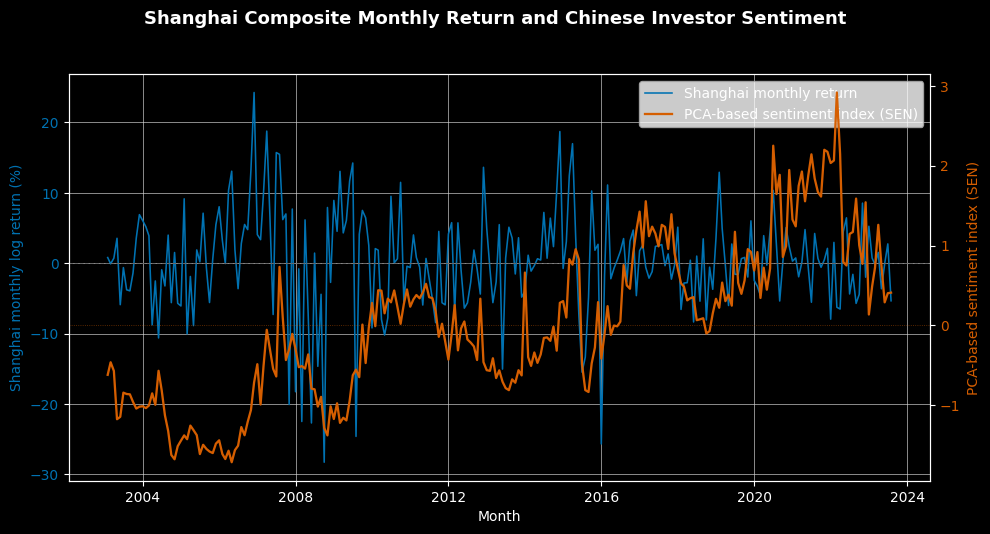

Saved dissertation figure to: C:\Users\20945\Desktop\data\project\dataset\outputs\figure_4_1_shanghai_return_sen.png


In [80]:
# Dissertation figure: Shanghai monthly return and PCA-based SEN.
import matplotlib.dates as mdates
plt.style.use("default")
# Separate y-axes are used because returns and SEN have different units and scales.
fig, ax_return = plt.subplots(figsize=(10, 5.4), facecolor="white")
ax_sen = ax_return.twinx()
ax_return.set_facecolor("white")
ax_sen.set_facecolor("none")

return_line = ax_return.plot(
    analysis_df["month_dt"],
    analysis_df["r_shanghai"],
    color="#0072B2",
    linewidth=1.15,
    label="Shanghai monthly return"
)
sen_line = ax_sen.plot(
    analysis_df["month_dt"],
    analysis_df["sen"],
    color="#D55E00",
    linewidth=1.65,
    label="SEN"
)

ax_return.axhline(0, color="#666666", linewidth=0.7, linestyle="--")
ax_sen.axhline(0, color="#D55E00", linewidth=0.6, linestyle=":", alpha=0.55)
ax_return.set_xlabel("Month")
ax_return.set_ylabel("Shanghai monthly log return (%)", color="#0072B2")
ax_sen.set_ylabel("PCA-based sentiment index (SEN)", color="#D55E00")
ax_return.tick_params(axis="both", colors="#222222", labelsize=10)
ax_sen.tick_params(axis="y", colors="#222222", labelsize=10)
ax_return.xaxis.set_major_locator(mdates.YearLocator(4))
ax_return.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_return.grid(axis="both", color="#D9D9D9", linewidth=0.6, alpha=0.75)
ax_return.set_axisbelow(True)
for axis in (ax_return, ax_sen):
    for spine in axis.spines.values():
        spine.set_color("#444444")
        spine.set_linewidth(0.8)

lines = return_line + sen_line
legend = ax_return.legend(
    lines,
    [line.get_label() for line in lines],
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#B0B0B0"
)
for text in legend.get_texts():
    text.set_color("#222222")
fig.tight_layout()

figure_path = PROJECT_ROOT / "dataset" / "outputs" / "figure_4_1_shanghai_return_sen.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved dissertation figure to: {figure_path}")


## 5.10. Dissertation Figure: Correlations between Asian Market Returns and SEN

Display the contemporaneous Pearson correlations between the five Asian monthly return series and the PCA-constructed sentiment index used in the main models.


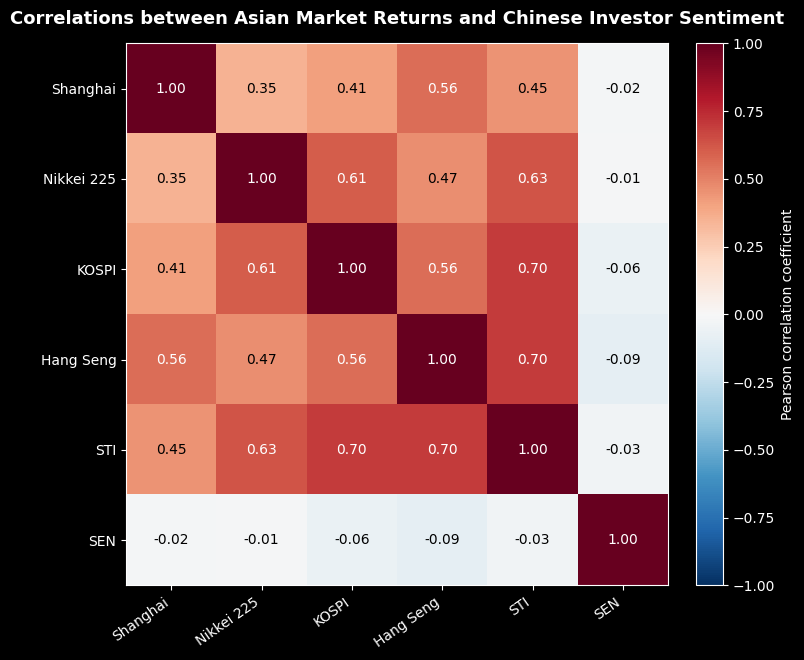

Saved dissertation heatmap to: C:\Users\20945\Desktop\data\project\dataset\outputs\figure_4_2_returns_sen_heatmap.png


In [81]:
# Dissertation heatmap: baseline monthly returns and PCA-based SEN.
plt.style.use("default")
heatmap_vars = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "sen"
]
heatmap_labels = ["Shanghai", "Nikkei 225", "KOSPI", "Hang Seng", "STI", "SEN"]
sen_corr_matrix = analysis_df[heatmap_vars].corr()

fig, ax = plt.subplots(figsize=(8.2, 6.7), facecolor="white")
ax.set_facecolor("white")
image = ax.imshow(sen_corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(heatmap_labels)), heatmap_labels, rotation=35, ha="right")
ax.set_yticks(range(len(heatmap_labels)), heatmap_labels)

for row in range(len(heatmap_labels)):
    for column in range(len(heatmap_labels)):
        value = sen_corr_matrix.iloc[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color="white" if abs(value) >= 0.55 else "black"
        )

ax.tick_params(axis="both", colors="#222222", labelsize=10)
for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(0.8)
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Pearson correlation coefficient", color="#222222")
colorbar.ax.tick_params(colors="#222222", labelsize=9)
fig.tight_layout()

heatmap_path = PROJECT_ROOT / "dataset" / "outputs" / "figure_4_2_returns_sen_heatmap.png"
fig.savefig(heatmap_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved dissertation heatmap to: {heatmap_path}")


# 6. Main Extended VAR Analysis: PCA-Based SEN and S&P 500

Estimate the main extended correlation, VAR and Granger-causality analysis using the PCA-constructed sentiment index (SEN) and the S&P 500 return.


## 6.1. Main Extended-Model Correlation: Returns and SEN

Compute pairwise correlations between market returns and the constructed sentiment index.


In [82]:
corr_vars_sen = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "sen"
]

corr_sen_table = correlation_table_html(
    analysis_df,
    corr_vars_sen,
    star_level=0.05
)


,r_shanghai,r_nikkei,r_kospi,r_hangseng,r_singapore,r_sp500,sen
r_shanghai,1.0000,,,,,,
r_nikkei,0.3477*0.0000,1.0000,,,,,
r_kospi,0.4113*0.0000,0.6068*0.0000,1.0000,,,,
r_hangseng,0.5592*0.0000,0.4680*0.0000,0.5589*0.0000,1.0000,,,
r_singapore,0.4491*0.0000,0.6292*0.0000,0.6957*0.0000,0.7031*0.0000,1.0000,,
r_sp500,0.3653*0.0000,0.6851*0.0000,0.6855*0.0000,0.5339*0.0000,0.6980*0.0000,1.0000,
sen,-0.02070.7464,-0.01410.8257,-0.06250.3277,-0.09280.1459,-0.03340.6016,0.03420.5927,1.0000


## 6.2. Main Extended-Model VAR Lag Selection: SEN, Max Lag 6

Select lag order for the VAR model using returns and the constructed sentiment index.


In [83]:
# sen VAR lag-order selection with maximum lag 6.
var_vars_sen = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "sen"
]

var_data_sen = analysis_df[var_vars_sen].dropna().copy()
var_model_sen = VAR(var_data_sen)

lag_order_sen_6 = var_model_sen.select_order(maxlags=6)
lag_order_sen_6.summary()


,AIC,BIC,FPE,HQIC
0,17.08,17.18,2.608e+07,17.12
1,15.28*,16.09*,4.328e+06*,15.61*
2,15.29,16.81,4.365e+06,15.90
3,15.45,17.67,5.133e+06,16.34
4,15.41,18.35,4.984e+06,16.60
5,15.46,19.10,5.248e+06,16.93
6,15.61,19.97,6.201e+06,17.37


## 6.3. Main Extended VAR(2) Model with SEN and S&P 500

Estimate the VAR model with two lags using market returns and the constructed sentiment index. Although the information criteria favor lag 1 in the extended model, lag 2 is used to maintain comparability with the baseline specification.


In [84]:
# Estimate the VAR(2) model with sen.
var_vars_sen = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "sen"
]

var_data_sen = analysis_df[var_vars_sen].dropna().copy()
var_model_sen = VAR(var_data_sen)

# fit(2) includes lags 1 and 2.
var_results_sen_lag2 = var_model_sen.fit(2)

print(var_results_sen_lag2.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Jul, 2026
Time:                     21:20:09
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    16.8016
Nobs:                     245.000    HQIC:                   15.9053
Log likelihood:          -4202.86    FPE:                4.42205e+06
AIC:                      15.3010    Det(Omega_mle):     2.91724e+06
--------------------------------------------------------------------
Results for equation r_shanghai
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.356055         0.477924            0.745           0.456
L1.r_shanghai          0.093033         0.079621            1.168           0.243
L1.r_nikkei           -0.049355         0.127977   

## 6.4. Full Main Extended VAR(2) Coefficient Table with SEN

Create a complete coefficient table for the VAR(2) model using sen.


In [85]:
# Complete coefficient table for the VAR(2) model with sen.
params = var_results_sen_lag2.params
stderr = var_results_sen_lag2.stderr
zvalues = var_results_sen_lag2.tvalues
pvalues = var_results_sen_lag2.pvalues

z_crit = norm.ppf(0.975)

base_variables = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "sen"
]

ordered_parameters = []
for base_var in base_variables:
    for lag_number in range(1, 3):
        ordered_parameters.append(f"L{lag_number}.{base_var}")
ordered_parameters.append("const")

rows = []

for equation in params.columns:
    for variable in ordered_parameters:
        if variable not in params.index:
            continue

        coef = params.loc[variable, equation]
        se = stderr.loc[variable, equation]
        z = zvalues.loc[variable, equation]
        p = pvalues.loc[variable, equation]
        ci_lower = coef - z_crit * se
        ci_upper = coef + z_crit * se

        if variable == "const":
            lag = "const"
            variable_name = "const"
        else:
            lag, variable_name = variable.split(".", 1)

        rows.append({
            "Equation": equation,
            "Variable": variable_name,
            "Lag": lag,
            "Coefficient": coef,
            "Std. err.": se,
            "z": z,
            "P>|z|": p,
            "95% CI lower": ci_lower,
            "95% CI upper": ci_upper
        })

var_sen_lag2_full_table = pd.DataFrame(rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

display(var_sen_lag2_full_table)


,Equation,Variable,Lag,Coefficient,Std. err.,z,P>|z|,95% CI lower,95% CI upper
0,r_shanghai,r_shanghai,L1,0.093033,0.079621,1.168440,2.426293e-01,-0.063022,0.249087
1,r_shanghai,r_shanghai,L2,0.097783,0.079230,1.234162,2.171426e-01,-0.057506,0.253072
2,r_shanghai,r_nikkei,L1,-0.049355,0.127977,-0.385654,6.997526e-01,-0.300184,0.201475
3,r_shanghai,r_nikkei,L2,-0.123344,0.129899,-0.949540,3.423462e-01,-0.377941,0.131253
4,r_shanghai,r_kospi,L1,0.035628,0.135779,0.262400,7.930127e-01,-0.230493,0.301750
5,r_shanghai,r_kospi,L2,0.211467,0.134688,1.570048,1.164039e-01,-0.052517,0.475452
6,r_shanghai,r_hangseng,L1,-0.025960,0.117609,-0.220730,8.253030e-01,-0.256470,0.204550
7,r_shanghai,r_hangseng,L2,-0.037796,0.112787,-0.335113,7.375402e-01,-0.258854,0.183262
8,r_shanghai,r_singapore,L1,0.063334,0.177517,0.356775,7.212605e-01,-0.284594,0.411261
9,r_shanghai,r_singapore,L2,0.353549,0.172307,2.051849,4.018438e-02,0.015832,0.691265


## 6.5. Main Extended VAR(2) Stability Test with SEN

Check whether the VAR(2) model with sen satisfies the stability condition.


In [86]:
# Stability test using companion-matrix eigenvalues.
# The VAR is stable when all eigenvalue moduli are less than 1.
eigenvalues_sen_lag2 = 1 / var_results_sen_lag2.roots

stability_table_sen_lag2 = pd.DataFrame({
    "Eigenvalue": eigenvalues_sen_lag2,
    "Modulus": np.abs(eigenvalues_sen_lag2)
})

stability_table_sen_lag2 = stability_table_sen_lag2.sort_values(
    by="Modulus",
    ascending=False
).reset_index(drop=True)

display(stability_table_sen_lag2)

if np.all(stability_table_sen_lag2["Modulus"] < 1):
    print("All eigenvalue moduli are less than 1.")
    print("VAR(2) with sen satisfies stability condition.")
else:
    print("At least one eigenvalue modulus is greater than or equal to 1.")
    print("VAR(2) with sen does not satisfy stability condition.")


,Eigenvalue,Modulus
0,0.951682+0.000000j,0.951682
1,-0.101026-0.564677j,0.573643
2,-0.101026+0.564677j,0.573643
3,0.455566+0.000000j,0.455566
4,-0.417588-0.000000j,0.417588
5,-0.361873-0.000000j,0.361873
6,0.356295+0.000000j,0.356295
7,0.069555-0.298114j,0.306121
8,0.069555+0.298114j,0.306121
9,-0.285677-0.080477j,0.296796


All eigenvalue moduli are less than 1.
VAR(2) with sen satisfies stability condition.


## 6.6. Main Extended VAR(2) Granger Causality Tests with SEN

Run Wald tests for Granger causality using the VAR(2) model with sen.


In [87]:
# Granger causality Wald tests using the VAR(2) model with sen.
var_names_sen = [
    "r_shanghai",
    "r_nikkei",
    "r_kospi",
    "r_hangseng",
    "r_singapore",
    "r_sp500",
    "sen"
]

granger_sen_lag2_rows = []

for equation in var_names_sen:
    excluded_vars = [var for var in var_names_sen if var != equation]

    # Test each excluded variable one by one.
    for excluded in excluded_vars:
        test_result = var_results_sen_lag2.test_causality(
            caused=equation,
            causing=excluded,
            kind="wald"
        )

        granger_sen_lag2_rows.append({
            "Equation": equation,
            "Excluded": excluded,
            "chi2": test_result.test_statistic,
            "df": test_result.df,
            "Prob > chi2": test_result.pvalue
        })

    # Test all other variables jointly.
    test_all = var_results_sen_lag2.test_causality(
        caused=equation,
        causing=excluded_vars,
        kind="wald"
    )

    granger_sen_lag2_rows.append({
        "Equation": equation,
        "Excluded": "ALL",
        "chi2": test_all.test_statistic,
        "df": test_all.df,
        "Prob > chi2": test_all.pvalue
    })

granger_sen_lag2_table = pd.DataFrame(granger_sen_lag2_rows)

granger_sen_lag2_table_formatted = granger_sen_lag2_table.copy()
granger_sen_lag2_table_formatted["chi2"] = granger_sen_lag2_table_formatted["chi2"].map(lambda x: f"{x:.4f}")
granger_sen_lag2_table_formatted["Prob > chi2"] = granger_sen_lag2_table_formatted["Prob > chi2"].map(lambda x: f"{x:.3f}")

display(granger_sen_lag2_table_formatted)


,Equation,Excluded,chi2,df,Prob > chi2
0,r_shanghai,r_nikkei,1.0592,2,0.589
1,r_shanghai,r_kospi,2.4888,2,0.288
2,r_shanghai,r_hangseng,0.1486,2,0.928
3,r_shanghai,r_singapore,4.3124,2,0.116
4,r_shanghai,r_sp500,5.6877,2,0.058
5,r_shanghai,sen,0.8702,2,0.647
6,r_shanghai,ALL,13.8788,12,0.309
7,r_nikkei,r_shanghai,2.5299,2,0.282
8,r_nikkei,r_kospi,2.7410,2,0.254
9,r_nikkei,r_hangseng,0.7617,2,0.683
